<a href="https://colab.research.google.com/github/joodali25/IT326-DataMining-Project/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification (Decision Tree)


In this section, Decision Tree classification is applied to the dataset using two attribute selection measures: Gini index and Entropy. The model is evaluated using three different train-test splits: 70/30, 80/20, and 90/10. The performance is measured using accuracy and confusion matrix.

In [44]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

repo_path = "/content/IT326-DataMining-Project"

if not os.path.exists(repo_path):
    !git clone https://github.com/joodali25/IT326-DataMining-Project.git

file_path = "/content/IT326-DataMining-Project/Dataset/Preprocessed_dataset.csv"
df = pd.read_csv(file_path)

X = df.drop("Depression", axis=1)
y = df["Depression"]

In [45]:
def run_decision_tree(test_size, criterion_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    model = DecisionTreeClassifier(criterion=criterion_name, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("======================================")
    print(f"Split: {int((1-test_size)*100)}/{int(test_size*100)}")
    print(f"Criterion: {criterion_name}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    return acc, cm

In [46]:
results = []

# 70/30
acc, cm = run_decision_tree(0.30, "gini")
results.append(["70/30", "Gini", acc, cm])

acc, cm = run_decision_tree(0.30, "entropy")
results.append(["70/30", "Entropy", acc, cm])

# 80/20
acc, cm = run_decision_tree(0.20, "gini")
results.append(["80/20", "Gini", acc, cm])

acc, cm = run_decision_tree(0.20, "entropy")
results.append(["80/20", "Entropy", acc, cm])

# 90/10
acc, cm = run_decision_tree(0.10, "gini")
results.append(["90/10", "Gini", acc, cm])

acc, cm = run_decision_tree(0.10, "entropy")
results.append(["90/10", "Entropy", acc, cm])

Split: 70/30
Criterion: gini
Accuracy: 0.8477
Confusion Matrix:
[[60 11]
 [12 68]]
Split: 70/30
Criterion: entropy
Accuracy: 0.8609
Confusion Matrix:
[[61 10]
 [11 69]]
Split: 80/20
Criterion: gini
Accuracy: 0.8812
Confusion Matrix:
[[41  7]
 [ 5 48]]
Split: 80/20
Criterion: entropy
Accuracy: 0.8911
Confusion Matrix:
[[42  6]
 [ 5 48]]
Split: 90/10
Criterion: gini
Accuracy: 0.8627
Confusion Matrix:
[[19  5]
 [ 2 25]]
Split: 90/10
Criterion: entropy
Accuracy: 0.8824
Confusion Matrix:
[[20  4]
 [ 2 25]]


In [47]:
results_df = pd.DataFrame(results, columns=["Split", "Criterion", "Accuracy", "Confusion Matrix"])
results_df

,Split,Criterion,Accuracy,Confusion Matrix
0,70/30,Gini,0.847682,"[[60, 11], [12, 68]]"
1,70/30,Entropy,0.860927,"[[61, 10], [11, 69]]"
2,80/20,Gini,0.881188,"[[41, 7], [5, 48]]"
3,80/20,Entropy,0.891089,"[[42, 6], [5, 48]]"
4,90/10,Gini,0.862745,"[[19, 5], [2, 25]]"
5,90/10,Entropy,0.882353,"[[20, 4], [2, 25]]"


## Classification Results

The Decision Tree classifier was tested using three different train-test splits (70/30, 80/20, and 90/10) and two splitting criteria (Gini and Entropy). The results show the accuracy for each experiment, along with the corresponding confusion matrix. These results help in identifying the best-performing split and criterion for predicting student depression.

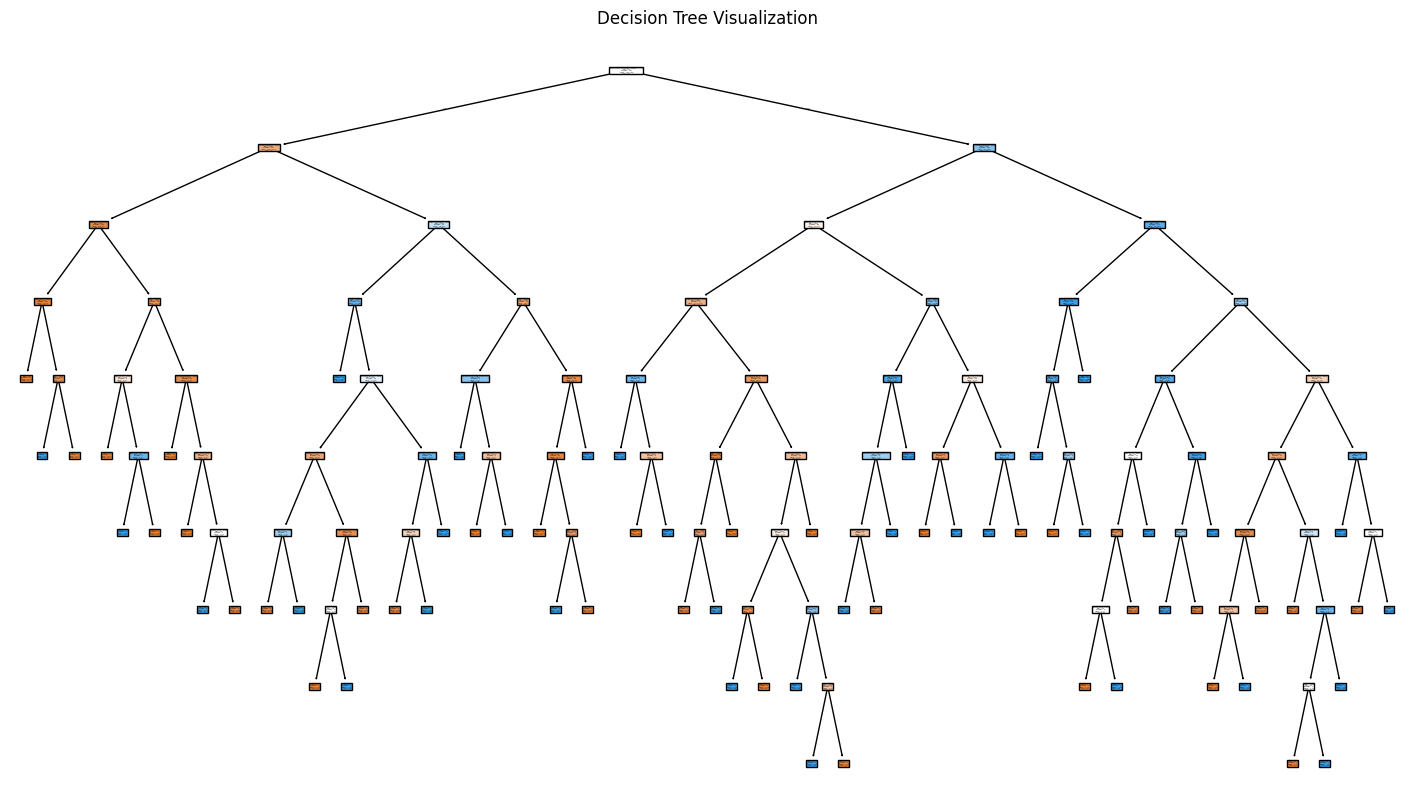

In [48]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

model = DecisionTreeClassifier(criterion="gini", random_state=42)
model.fit(X, y)

plt.figure(figsize=(18,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=["No", "Yes"])
plt.title("Decision Tree Visualization")
plt.show()

## Clustering (K-Means)

In this section, we apply K-means clustering on the preprocessed dataset to identify groups of students with similar characteristics.

We experiment with different values of K (number of clusters) and evaluate the performance using:
- Silhouette Score
- Elbow Method (WCSS)

We also visualize the clusters to better understand the data distribution.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
repo_path = "/content/IT326-DataMining-Project"

if not os.path.exists(repo_path):
    !git clone https://github.com/joodali25/IT326-DataMining-Project.git

file_path = "/content/IT326-DataMining-Project/Dataset/Preprocessed_dataset.csv"
df = pd.read_csv(file_path)

df.head()

In [35]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['Gender', 'Age', 'Academic Pressure', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Cluster']


In [36]:
# Remove class label if exists
if "Depression" in df.columns:
    X = df.drop(columns=["Depression"])
else:
    X = df.copy()

# Keep only numeric
X = X.select_dtypes(include=[np.number])

# Fill missing values
X = X.fillna(X.mean())

print("Shape:", X.shape)
X.head()

Shape: (502, 11)


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Cluster
0,1.0,0.6250,0.25,0.75,0.333333,0.5,1.0,0.750000,0.25,1.0,0
1,1.0,0.6250,0.75,1.00,0.000000,0.0,1.0,0.583333,0.00,1.0,0
2,1.0,0.4375,0.00,0.50,0.000000,1.0,1.0,0.833333,0.75,0.0,0
3,1.0,0.3125,0.00,0.75,1.000000,1.0,1.0,0.583333,0.25,1.0,0
4,0.0,0.8125,0.00,1.00,1.000000,0.0,1.0,0.333333,0.25,1.0,1


In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully")

Data scaled successfully


In [38]:
k_values = [2, 3, 4]

wcss = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    "K": k_values,
    "WCSS": wcss,
    "Silhouette Score": sil_scores
})

results

,K,WCSS,Silhouette Score
0,2,4504.547285,0.178025
1,3,4248.211437,0.124868
2,4,4016.755614,0.104315


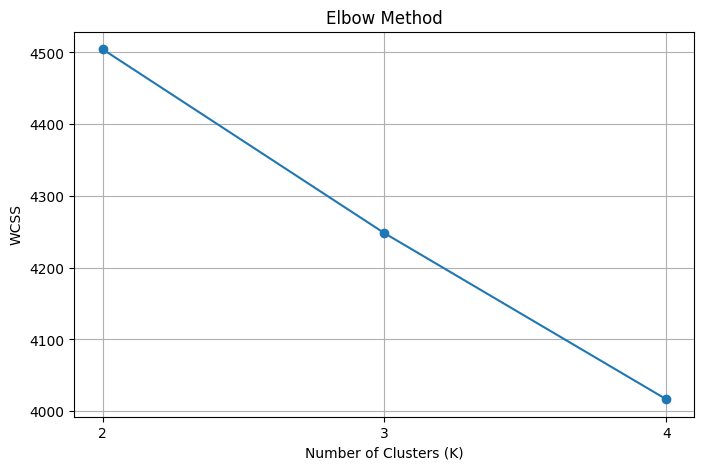

In [39]:
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(k_values)
plt.grid(True)
plt.show()

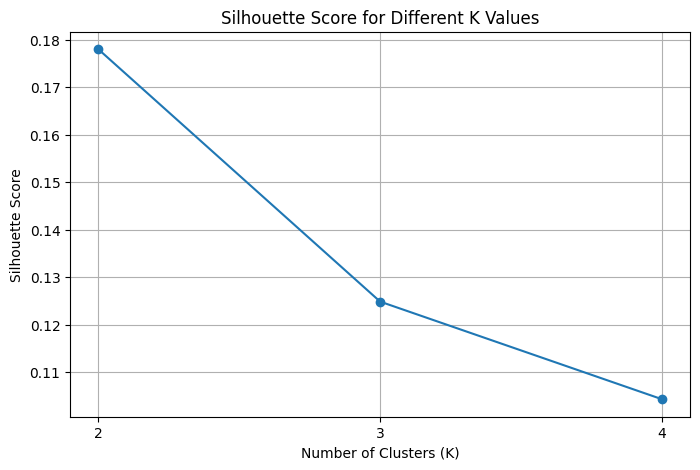

In [40]:
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [41]:
best_k = k_values[np.argmax(sil_scores)]
print("Best K =", best_k)

Best K = 2


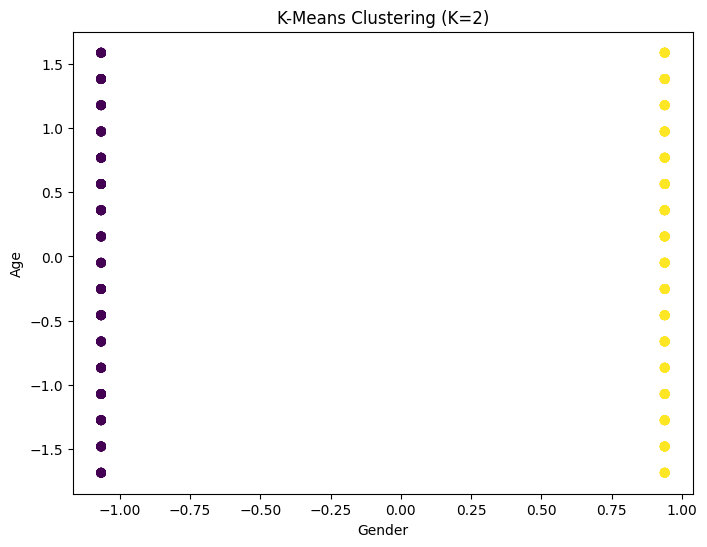

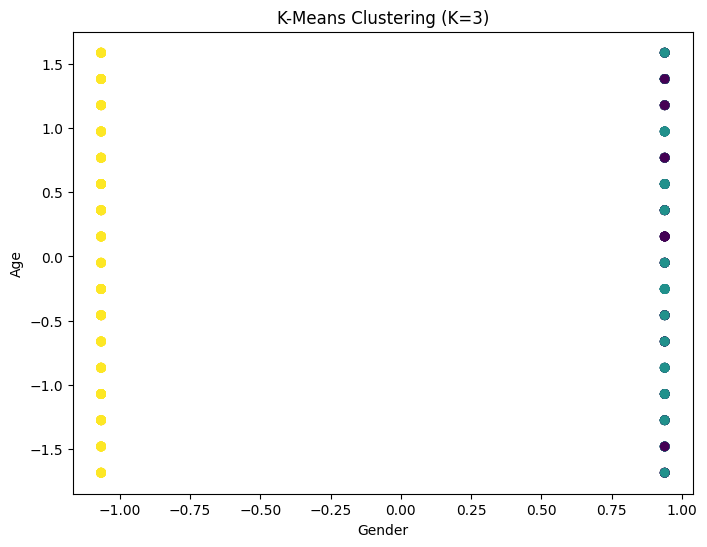

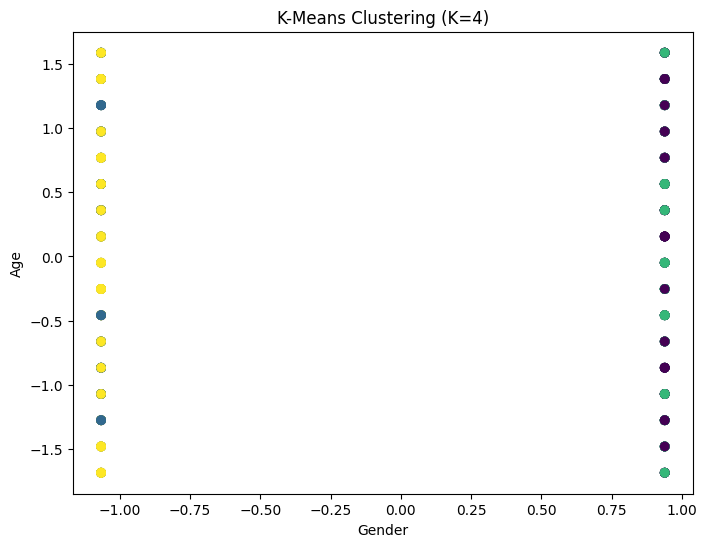

In [42]:
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
    plt.title(f"K-Means Clustering (K={k})")
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.show()

In [43]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(X_scaled)

df["Cluster"] = final_labels

df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression,Cluster
0,1.0,0.6250,0.25,0.75,0.333333,0.5,1.0,0.750000,0.25,1.0,0,1
1,1.0,0.6250,0.75,1.00,0.000000,0.0,1.0,0.583333,0.00,1.0,0,1
2,1.0,0.4375,0.00,0.50,0.000000,1.0,1.0,0.833333,0.75,0.0,1,1
3,1.0,0.3125,0.00,0.75,1.000000,1.0,1.0,0.583333,0.25,1.0,0,1
4,0.0,0.8125,0.00,1.00,1.000000,0.0,1.0,0.333333,0.25,1.0,0,0


## Clustering Evaluation

We applied K-means clustering using three different values of K: 2, 3, and 4.

To evaluate clustering performance, we used:
- Silhouette Score
- Elbow Method (WCSS)

The results showed that:
- K = 2 achieved the highest silhouette score, indicating better cluster separation.
- K = 3 and K = 4 reduced WCSS, but their silhouette scores were lower.
- Based on the majority rule, K = 2 was selected as the optimal number of clusters.

The visualization of clusters for different K values helped in understanding the separation between student groups.